# Begin

In [2]:
# @launchit.collected

In [3]:
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

import sys
import os
from collections import namedtuple # @launchit.collect
from pathlib import Path
import json
import datetime
import pprint
from functools import cache
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import importlib.util

if importlib.util.find_spec('cuml') is not None:
    print('Running with CuML')
    import cuml
    cuml.accel.install(log_level="debug")
else:
    print('Running without CuML')
    
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV

import torch
import torch.nn as tnn
import torch.nn.functional as tnnf
import torch.optim as topt
from torch.utils.data import DataLoader, StackDataset
from torchvision import datasets

sys.path.append(project_root_path)
from lib.utils import *
from lib.logging import *
from lib.model_registry import *
import lib.launchit # @launchit.disable
from lib.metrics_collector import RmqSummaryWriter

Running without CuML


# Setup

In [4]:
LOG = Logging()
RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, data_path, mnist_path, metrics_path, ' + 
                    'notebook_fname, notebook_name, is_cuda, cuda_device, is_launch, is_cuml')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    metrics_path=os.path.expanduser('~/tensorboard'),
    notebook_fname='noname.ipynb',
    notebook_name='noname',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    is_launch=False,
    is_cuml=importlib.util.find_spec('cuml') is not None,
)

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)

    m = re.match(r'(\w+)-Copy\d+$', notebook_name)

    if m:
        # Cuml is used to be launched from the copy of the notebook
        notebook_name = m.group(1)
    
    CONFIG = CONFIG._replace(notebook_fname=notebook_fname, notebook_name=notebook_name, is_launch=not re.match(r'\w+-launch\d+$', notebook_name) is None)

print('CONFIG=\n' + pprint.pformat(CONFIG._asdict()))
print('')

# @launchit.disable
# @launchit.collect
MODEL_INSTANCE_INFO = namedtuple('ModelInstanceInfo', 'group_uri, name, version, main_asset_fname')(
    group_uri='${MODEL_GROUP_URI}',
    name='${MODEL_NAME}',
    version='${MODEL_VERSION}',
    main_asset_fname='${LAUNCHIT_FNAME}'
)
# @launchit.stop

MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(group_uri=f'{CONFIG.project_root_uri}.{os.path.basename(os.path.dirname(notebook_fname))}')
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(name=CONFIG.notebook_name)
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version='')
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(main_asset_fname=CONFIG.notebook_fname)
# @launchit.stop

print('MODEL_INSTANCE_INFO=\n' + pprint.pformat(MODEL_INSTANCE_INFO._asdict()))

CONFIG=
{'cuda_device': 'cpu',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'is_cuda': False,
 'is_cuml': False,
 'is_launch': False,
 'metrics_path': '/home/misha/tensorboard',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'notebook_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_07.ipynb',
 'notebook_name': 's3_stacked_dae_07',
 'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision'}

MODEL_INSTANCE_INFO=
{'group_uri': 'com.develorium.neurovision.denoise',
 'main_asset_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_07.ipynb',
 'name': 's3_stacked_dae_07',
 'version': ''}


# Hyperparameters

In [5]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    override_pretrain_model_version: int = None
    
    @dataclass
    class Images:
        preprocessing: str = None
        
    @dataclass
    class PretrainModel:
        daes_count: int = None
        filters_count: int = None
        is_tied_weights: bool = None
        is_bias: bool = None
        nonlinearity: dict = None

    @dataclass
    class Pretraining:
        batch_size: int = None
        epochs_count: int = None
        optimizer: str = None
        learn_rate: float = None
        noise: str = None
        loss: str = None
        regularization: dict = None

    @dataclass
    class Training:
        batch_size: int = None
        epochs_count: int = None
        optimizer: str = None
        learn_rate: float = None
        
    images: Images = dataclasses.field(default_factory=Images)
    pretrain_model: PretrainModel = dataclasses.field(default_factory=PretrainModel)
    pretraining: Pretraining = dataclasses.field(default_factory=Pretraining)
    training: Training = dataclasses.field(default_factory=Training)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.images = Hyperparameters.Images(**hp.images)
        hp.pretrain_model = Hyperparameters.PretrainModel(**hp.pretrain_model)
        hp.pretraining = Hyperparameters.Pretraining(**hp.pretraining)
        hp.training = Hyperparameters.Training(**hp.training)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 82
HP.override_pretrain_model_version = None


# Launch

## new_model_registry

In [6]:
def new_model_registry(is_real=None):
    is_real = is_real if is_real is not None else CONFIG.is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(MODEL_INSTANCE_INFO.group_uri)

## new_summary_writer

In [7]:
def new_summary_writer(log_dir, is_real=None):
    is_real = is_real if is_real is not None else CONFIG.is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## launchit

In [8]:
# @launchit.disable
launchit_t0 = time.time()

In [9]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_registry = new_model_registry(is_real=True)
    new_model_instance_version = model_registry.register_model(MODEL_INSTANCE_INFO.name)
    print(f'Model instance registered, version={new_model_instance_version}')
    
    expandvars = dict(
        MODEL_GROUP_URI=MODEL_INSTANCE_INFO.group_uri,
        MODEL_NAME=MODEL_INSTANCE_INFO.name,
        MODEL_VERSION=new_model_instance_version,
    )
    lib.launchit.launchit(CONFIG.notebook_fname, launch_serial=new_model_instance_version, expandvars=expandvars)
else:
    print('Skip launchit due to mass "Run Cells"')

Skip launchit due to mass "Run Cells"


## Bootstrap

In [10]:
model_registry = new_model_registry()
model_registry.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, CONFIG.notebook_fname, replace=True)
    
meta = dict(hypers=HP._asdict(), config=CONFIG._asdict())

with io.StringIO() as b:
    json.dump(meta, b)
    model_registry.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'meta', replace=True)

summary_log_dir = os.path.join(MODEL_INSTANCE_INFO.name, str(MODEL_INSTANCE_INFO.version))
print(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict()), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict()), 1)

if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    print(f'Torch random seed={HP.random_seed}')

Tensorboard run=s3_stacked_dae_07/
Torch random seed=82


# Images

In [11]:
# @launchit.disable
# @launchit.collect
HP.images.preprocessing = 'UNINORM' # NONE, UNINORM, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN

## get_mnist_images

In [12]:
def get_mnist_images(subdataset='TRAIN'):
    assert subdataset in ['TRAIN', 'TEST'], f'Unsupported subdataset={subdataset}'
    d = datasets.MNIST(CONFIG.mnist_path, train=subdataset=='TRAIN', download=True)
    images = d.data.reshape(len(d.data), -1)
    images = images.numpy()
    images = images.astype('float32')
    image_labels = d.targets
    return images, image_labels

## UninormScaler

In [13]:
class UninormScaler:
    def __init__(self, divisor=255.0):
        self.divisor = divisor
        
    def fit_transform(self, images):
        return self.transform(images)

    def transform(self, images):
        return images / self.divisor

## preprocess_images

In [14]:
def preprocess_images(images, preprocessing_method, scaler=None):
    match preprocessing_method:
        case 'UNINORM':
            scaler = UninormScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'MIN_MAX':
            scaler = MinMaxScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'STANDARDIZE':
            scaler = StandardScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'ZCA_WHITEN':
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
            
            Σ = np.cov(images, rowvar=False)
            u, s, _ = np.linalg.svd(Σ)
            images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ images.T).T
        case 'ZCA_HFR30_WHITEN': # HFR30 - Remove 30% of High Frequencies
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
    
            Σ = np.cov(images, rowvar=False)
            eigvals, eigvecs = np.linalg.eig(Σ)
            eigvals_order = np.argsort(-eigvals)
            wipeout_inds = eigvals_order[int(len(eigvals_order) * (1 - 0.3)):]
            eigvals_w = eigvals.copy()
            eigvals_w[wipeout_inds] = 0
            
            R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
            S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
            R_inv = R.T
            W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
            images = (W @ images.T).T
        case 'NONE':
            pass
        case _:
            assert False, f'Unsupported preprocessing_method={preprocessing_method}'

    return images, scaler

# Noising

## gauss_noise

In [15]:
def gauss_noise(items, gadds_tab):
    if items.ndim == 2:
        assert items.shape[1] == gadds_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {gadds_tab.shape[1]}'
        items_count = len(items)
        noise = gadds_tab[RNG.choice(len(gadds_tab), items_count)]
    elif items.ndim == 1:
        gadd_ind = RNG.choice(len(gadds_tab))
        noise = gadds_tab[gadd_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        return items + noise
    elif isinstance(items, torch.Tensor):
        return items + torch.tensor(noise, device=items.device, dtype=items.dtype)

## masking_noise

In [16]:
def masking_noise(items, masks_tab, fill_value=0):
    if items.ndim == 2:
        assert items.shape[1] == masks_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {masks_tab.shape[1]}'
        items_count = len(items)
        mask_inds = RNG.choice(len(masks_tab), items_count, replace=False)
        boolmap = masks_tab[mask_inds]
    elif items.ndim == 1:
        mask_ind = RNG.choice(len(masks_tab))
        boolmap = masks_tab[mask_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        noised = items.copy()
    elif isinstance(items, torch.Tensor):
        noised = items.clone()
    else:
        assert False, f'Unsupported type(items): {type(items)}'

    noised[boolmap] = fill_value
    return noised

## generate_zmasks

In [17]:
def generate_zmasks(ν, item_size, count):
    assert 0 <= ν <= 1
    zero_inds_count = int(ν * item_size)
    zmasks = np.full((count, item_size), False)
    
    for i in range(count):
        zero_inds = RNG.choice(item_size, zero_inds_count, replace=False)
        zmasks[i,zero_inds] = True

    return zmasks    

## Demo

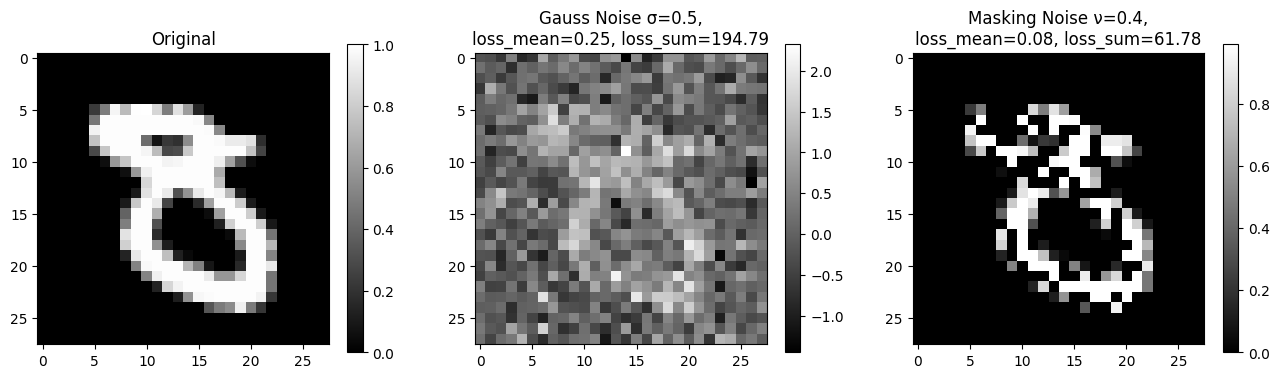

In [18]:
# @launchit.disable
images, _ = get_mnist_images()
images, _ = preprocess_images(images, HP.images.preprocessing)
image_ind = RNG.choice(len(images))
image = images[image_ind]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.set_title('Original')
im = ax1.imshow(ArrayUtils.v2sm(image), cmap='gray');
fig.colorbar(im, ax=ax1, shrink=.5)

σ = 0.5
gadds = RNG.normal(0, σ, (100, image.shape[0]))
noised = gauss_noise(image.ravel(), gadds)
noised = noised.reshape(image.shape)
ax2.set_title(f'Gauss Noise σ={σ},\nloss_mean={((image - noised)**2).mean():.2f}, loss_sum={((image - noised)**2).sum():.2f}')
im = ax2.imshow(ArrayUtils.v2sm(noised), cmap='gray');
fig.colorbar(im, ax=ax2, shrink=.5)

ν = 0.4
zmasks = generate_zmasks(ν, image.shape[0], 100)
noised = masking_noise(image.ravel(), zmasks, fill_value=0)
noised = noised.reshape(image.shape)
ax3.set_title(f'Masking Noise ν={ν},\nloss_mean={((image - noised)**2).mean():.2f}, loss_sum={((image - noised)**2).sum():.2f}')
im = ax3.imshow(ArrayUtils.v2sm(noised), cmap='gray');
fig.colorbar(im, ax=ax3, shrink=.5);

# Unsupervised pretraining

## Dataset

In [19]:
pretrain_dataset, _ = get_mnist_images('TRAIN')
pretrain_dataset, _ = preprocess_images(pretrain_dataset, HP.images.preprocessing)
pretrain_dataset = torch.Tensor(pretrain_dataset)
pretrain_dataset = pretrain_dataset.contiguous() # force dense memory layout (speeds up DataLoader x2)

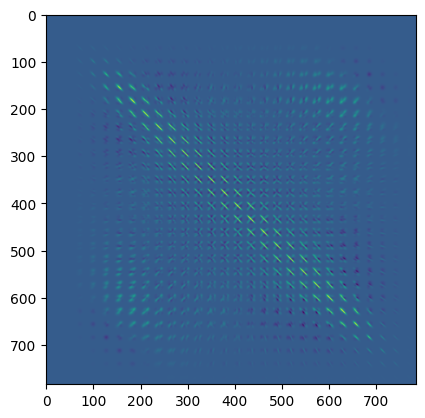

In [20]:
# @launchit.disable
plt.imshow(np.cov(pretrain_dataset, rowvar=False));

## Model: StackedDAE

In [21]:
class DenoiseAutoencoder(tnn.Module):
    def __init__(self, inp_dims_count, model_hp):
        super().__init__()
        self.encoder = tnn.Linear(inp_dims_count, model_hp.filters_count, bias=model_hp.is_bias) # aka filters
        # all weights are initialized by default via init.kaiming_uniform_ 

        if model_hp.is_tied_weights:
            self.decoder = None
            self.decoder_bias = tnn.Parameter(torch.randn(inp_dims_count)) if model_hp.is_bias else None
        else:
            self.decoder = tnn.Linear(model_hp.filters_count, inp_dims_count, bias=model_hp.is_bias)
            self.decoder_bias = None

        nonlinearities = {None: lambda x: x, 'sigmoid': tnnf.sigmoid}
        nonlinearity = {} if model_hp.nonlinearity is None else model_hp.nonlinearity
        self.encoder_nonlinearity = nonlinearities[nonlinearity.get('encoder', None)]
        self.decoder_nonlinearity = nonlinearities[nonlinearity.get('decoder', None)]

    def forward(self, inp):
        encoded = self.encode(inp)
        decoded = self.decode(encoded)
        return decoded, encoded

    def encode(self, inp):
        return self.encoder_nonlinearity(self.encoder(inp))

    def decode(self, inp):
        if self.decoder is None:
            # tied weights
            res = tnnf.linear(inp, self.encoder.weight.t(), self.decoder_bias)
        else:
            res = self.decoder(inp)
            
        return self.decoder_nonlinearity(res) 

class StackedDAE(tnn.Module):
    def __init__(self, inp_dims_count, model_hp):
        super().__init__()
        self.daes = tnn.ModuleList()

        current_inp_dims_count = inp_dims_count
        
        for i in range(model_hp.daes_count):
            dae = DenoiseAutoencoder(current_inp_dims_count, model_hp)
            current_inp_dims_count = model_hp.filters_count
            self.daes.append(dae)

    def encode(self, inp, daes_count=-1):
        daes_count = len(self.daes) if daes_count == -1 else daes_count
        
        for i in range(0, daes_count):
            dae = self.daes[i]
            inp = dae.encode(inp)

        return inp

In [22]:
model_hp = Hyperparameters.PretrainModel(daes_count=3, filters_count=1000, is_tied_weights=True, is_bias=True, nonlinearity={'encoder': 'sigmoid', 'decoder': None})
pretrain_model = StackedDAE(pretrain_dataset.shape[1], model_hp)
sum([p.numel() for p in pretrain_model.parameters()])

2789784

In [23]:
data_loader = DataLoader(pretrain_dataset, batch_size=100)
batch = next(iter(data_loader))

# ascention stage
with torch.no_grad():
    for i in range(len(pretrain_model.daes)):
        save_shape = batch.shape
        batch = pretrain_model.daes[i].encode(batch)
        print(f'Encoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')

# descention stage
with torch.no_grad():
    for i in reversed(range(len(pretrain_model.daes))):
        save_shape = batch.shape
        batch = pretrain_model.daes[i].decode(batch)
        print(f'Decoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')    

Encoding by DAE_0, batch shape=torch.Size([100, 784])->torch.Size([100, 1000])
Encoding by DAE_1, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Encoding by DAE_2, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Decoding by DAE_2, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Decoding by DAE_1, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Decoding by DAE_0, batch shape=torch.Size([100, 1000])->torch.Size([100, 784])


## Pretraining

In [24]:
@cache
def gadds(σ, item_size, gadds_count):
    return RNG.normal(0, σ, (gadds_count, item_size)).astype(float) 

@cache
def zmasks(ν, item_size, masks_count):
    return generate_zmasks(ν, item_size, masks_count)

In [25]:
optimizers = {
    'SGD': lambda parameters, lr: topt.SGD(parameters, lr),
    'Adam': lambda parameters, lr: topt.Adam(parameters, lr),
}

noise_funcs = {
    'None': lambda items: items,
    'Gauss_0.5': lambda items: gauss_noise(items, gadds(0.5, items.shape[1], 250_000)),
    'Masking_0': lambda items: masking_noise(items, zmasks(0, items.shape[1], 250_000)),
    'Masking_0.1': lambda items: masking_noise(items, zmasks(0.1, items.shape[1], 250_000)),
    'Masking_0.25': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], 250_000)),
    'Masking_0.25_1': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], 250_000), fill_value=1),
    'Masking_0.3': lambda items: masking_noise(items, zmasks(0.3, items.shape[1], 250_000)),
    'Masking_0.4': lambda items: masking_noise(items, zmasks(0.4, items.shape[1], 250_000)),
    'Masking_0.55': lambda items: masking_noise(items, zmasks(0.55, items.shape[1], 250_000)),
    'Masking_0.6': lambda items: masking_noise(items, zmasks(0.6, items.shape[1], 250_000)),
}

losses = {
    # sigmoid is expected to be withing Model structure (decoder)
    'BCE': lambda: tnn.BCELoss(reduction='mean'), 
    # sigmoid is NOT expected to be within Model structure, since sigmoid is builtin into loss itself
    'BCEWithLogits': lambda: tnn.BCEWithLogitsLoss(reduction='mean'), 
    ### 
    'MSE': lambda: tnn.MSELoss(reduction='mean'),
}

regularizations = {
    # Over activations acting regularizers
    'log(1+a^2)': lambda a: torch.log(1 + a**2), # Olshausen (sparsenet)
    '|a|': lambda a: torch.abs(a), # L1 regularization
}

# @launchit.disable
# @launchit.collect
HP.pretrain_model.daes_count = 3
HP.pretrain_model.filters_count = 1_000
HP.pretrain_model.is_tied_weights = True
HP.pretrain_model.is_bias = True
HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}

HP.pretraining.batch_size = 1_000
HP.pretraining.epochs_count = 300
HP.pretraining.noise = 'Masking_0.4'
HP.pretraining.optimizer = 'Adam'
HP.pretraining.learn_rate = 0.01
HP.pretraining.loss = 'BCE'
HP.pretraining.regularization = None
# @launchit.stop
pprint.pprint(HP._asdict())

{'images': {'preprocessing': 'UNINORM'},
 'override_pretrain_model_version': None,
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 300,
                 'learn_rate': 0.01,
                 'loss': 'BCE',
                 'noise': 'Masking_0.4',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': 82,
 'training': {'batch_size': None,
              'epochs_count': None,
              'learn_rate': None,
              'optimizer': None}}


In [26]:
def compute_regularized_loss(inferred, target, activations, loss_fn, regularization):
    loss = loss_fn(inferred, target) # args order: input, target

    if regularization is not None and regularization['c'] > 0:
        c = regularization['c']
        reg_fn = regularizations[regularization['fn']]
        s = reg_fn(activations).sum(axis=1) # compute per sample 
        loss += (c * s).mean()
    
    return loss

In [27]:
# pt_data = model_registry.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'pretrain')
# pt_data = io.BytesIO(initial_bytes=pt_data)
# checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
# pretrain_model.load_state_dict(checkpoint['model_state_dict'])
# # optimizer.load_state_dict(checkpoint['optimizer_state_dict']) # TODO dictinct optimizer instances are used for distinct DAE, adapt this code if needed
# epoch = int(checkpoint['epoch'])
# print(f'Model instance loaded from version={MODEL_INSTANCE_INFO.version}, epoch={epoch}')

In [28]:
data_loader = DataLoader(pretrain_dataset, batch_size=HP.pretraining.batch_size, pin_memory=CONFIG.is_cuda, shuffle=True)
pretrain_model = StackedDAE(pretrain_dataset.shape[1], HP.pretrain_model)
pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
noise_func = noise_funcs[HP.pretraining.noise]
loss_fn = losses[HP.pretraining.loss]()
pretrain_model.train()
example_item_ind = RNG.choice(len(pretrain_dataset))

In [ ]:
for trained_dae_ind in tqdm(range(len(pretrain_model.daes)), 'DAE'):
    optimizer = optimizers[HP.pretraining.optimizer](pretrain_model.parameters(), lr=HP.pretraining.learn_rate)
    
    for epoch_ind in tqdm(range(HP.pretraining.epochs_count), 'Epoch'):
        local_epoch = epoch_ind + 1
        global_epoch = HP.pretraining.epochs_count * trained_dae_ind + local_epoch
        epoch_loss_sum, epoch_loss_denom = 0, 0
        
        for batch in data_loader:
            optimizer.zero_grad()
            
            batch = batch.to(device=CONFIG.cuda_device)
    
            with torch.no_grad():
                assert 0 <= trained_dae_ind < len(pretrain_model.daes)
    
                for i in range(trained_dae_ind):
                    batch = pretrain_model.daes[i].encode(batch)
    
            noised = noise_func(batch)
            reconstructed, activations = pretrain_model.daes[trained_dae_ind](noised)
    
            loss = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
            loss.backward()
            
            optimizer.step()
            
            epoch_loss_sum += loss.item() * len(batch)
            epoch_loss_denom += len(batch)

        assert epoch_loss_denom > 0
        epoch_loss = epoch_loss_sum / epoch_loss_denom
        summary_writer.add_scalar('pretrain_loss', epoch_loss, global_epoch)
        summary_writer.add_scalar(f'pretrain_loss_{trained_dae_ind}', epoch_loss, local_epoch)
    
        if (epoch_ind % 20) == 0:
            # Examples -> tensorboard            
            with torch.no_grad():
                fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'yticks': [], 'xticks': []})
                fig.set_figwidth(12)
                fig.set_figheight(3.5)
                
                batch = pretrain_dataset[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
                
                for i in range(trained_dae_ind):
                    batch = pretrain_model.daes[i].encode(batch)
                
                noised = noise_func(batch)
                reconstructed, activations = pretrain_model.daes[trained_dae_ind](noised)
                reconstructed = reconstructed.to(device='cpu').detach()
                activations = activations.to(device='cpu').detach()
                noised = noised.to(device='cpu').detach()
                batch = batch.to(device='cpu')
                
                im = ax1.imshow(ArrayUtils.v2sm(batch.numpy().ravel(), 0))
                fig.colorbar(im, ax=ax1)
                im = ax2.imshow(ArrayUtils.v2sm(noised.numpy().ravel(), 0))
                fig.colorbar(im, ax=ax2)
                im = ax3.imshow(ArrayUtils.v2sm(reconstructed.numpy().ravel(), 0))
                fig.colorbar(im, ax=ax3)
                loss1 = compute_regularized_loss(batch, batch, activations, loss_fn, HP.pretraining.regularization)
                loss2 = compute_regularized_loss(noised, batch, activations, loss_fn, HP.pretraining.regularization)
                loss3 = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
                fig.suptitle(f'DAE {trained_dae_ind}, Loss Input/Noised/Reconstr.={loss1:.3f} / {loss2:.3f} / {loss3:.3f}');
                fig.tight_layout()
                summary_writer.add_figure(f'pretrain_example_{trained_dae_ind}', fig, local_epoch, close=True)
            
        if (epoch_ind % 20) == 0 and trained_dae_ind == 0:
            # Filters (first DAE only) -> tensorboard
            bases_in_row = 10
            max_filters_to_show = 100
            fig, axes = plt.subplots(
                int(np.ceil(min(max_filters_to_show, pretrain_model.daes[0].encoder.out_features) / bases_in_row)), 
                bases_in_row,
                subplot_kw={'yticks': [], 'xticks': []}
            )
            fig.set_figwidth(12)
            fig.set_figheight(18)
            filters = pretrain_model.daes[0].encoder.weight.to(device='cpu').detach()
            
            for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
                ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
                ax.imshow(ArrayUtils.v2sm(f), cmap='gray')
            
            fig.tight_layout()
            summary_writer.add_figure(f'pretrain_filters_{trained_dae_ind}', fig, local_epoch, close=True)
        
        summary_writer.flush()

## Save

In [32]:
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': pretrain_model.state_dict(),
        # 'optimizer_state_dict': optimizer.state_dict(), # TODO dictinct optimizer instances are used for distinct DAE, adapt this code if needed
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'pretrain_pt', replace=True)

## Visualization

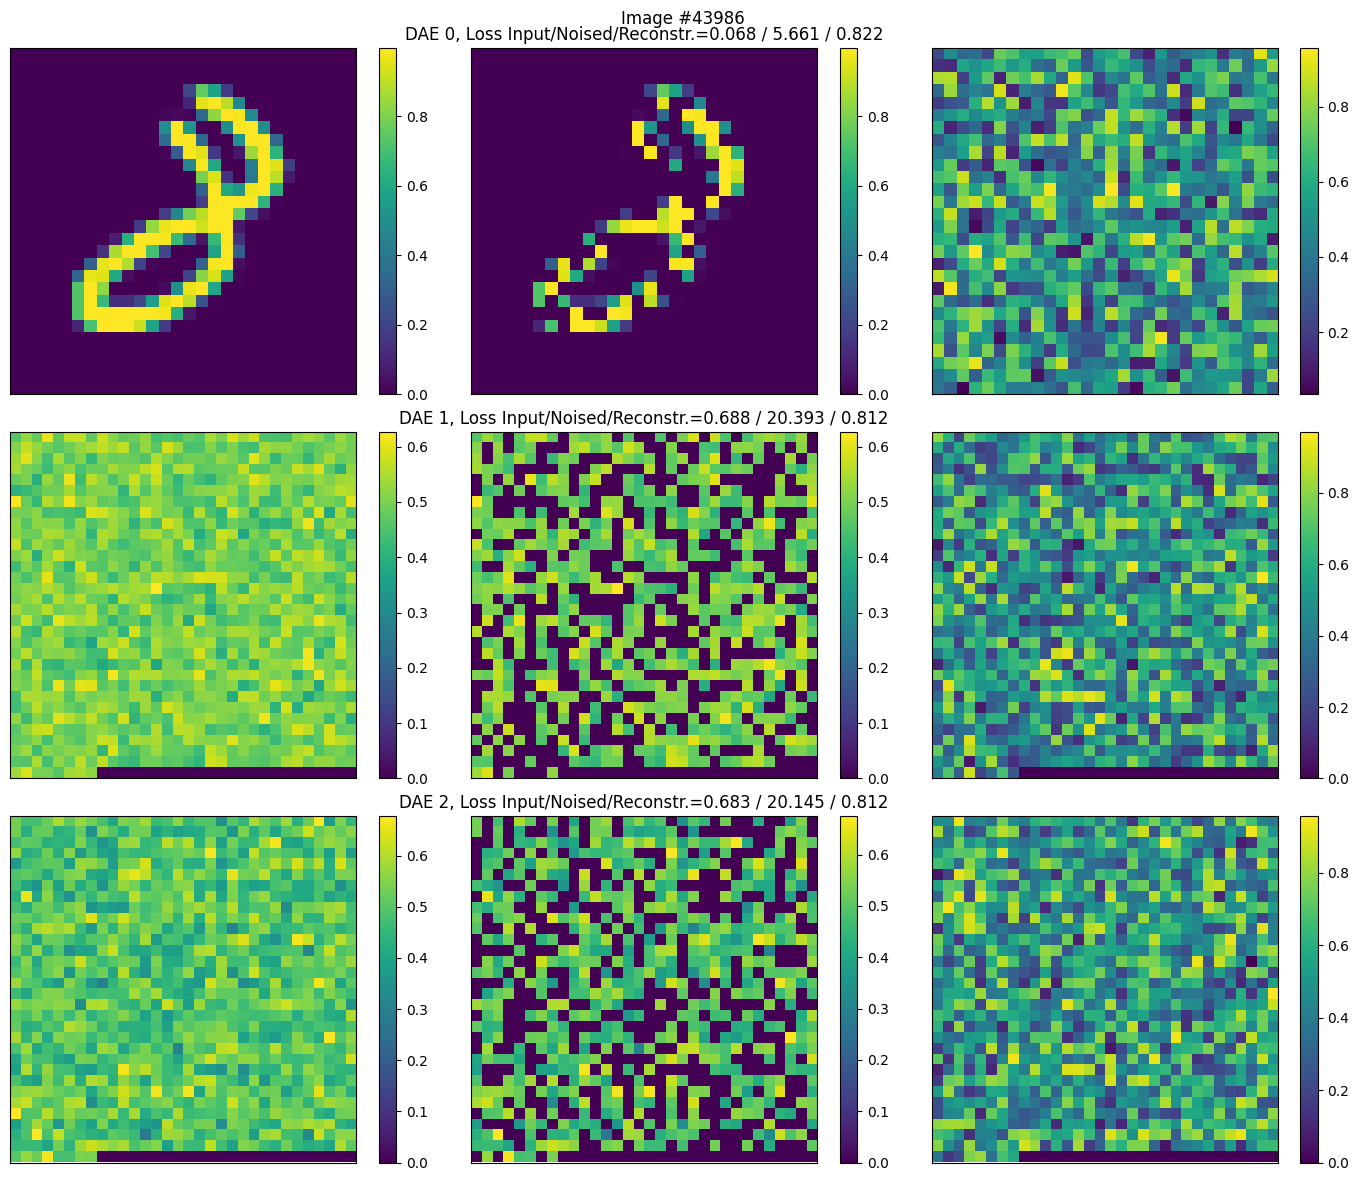

In [46]:
# @launchit.disable
fig, axes = plt.subplots(3, 3, subplot_kw={'yticks': [], 'xticks': []})
axes = axes.ravel()
fig.set_figwidth(14)
fig.set_figheight(4 * 3)

example_item_ind = RNG.choice(len(pretrain_dataset))
noise_func = noise_funcs[HP.pretraining.noise]
pretrain_model.eval()
loss_fn = losses[HP.pretraining.loss]()

with torch.no_grad():
    for target_dae_ind, base_ax_ind in zip(range(len(pretrain_model.daes)), range(len(axes))[::3]):
        batch = pretrain_dataset[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
    
        for i in range(target_dae_ind):
            batch = pretrain_model.daes[i].encode(batch)

        noised = noise_func(batch)
        reconstructed, activations = pretrain_model.daes[target_dae_ind](noised)
        reconstructed = reconstructed.to(device='cpu').detach()
        activations = activations.to(device='cpu').detach()
        noised = noised.to(device='cpu').detach()
        batch = batch.to(device='cpu')

        ax1, ax2, ax3 = axes[base_ax_ind], axes[base_ax_ind+1], axes[base_ax_ind+2]

        im = ax1.imshow(ArrayUtils.v2sm(batch.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax1)
        im = ax2.imshow(ArrayUtils.v2sm(noised.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax2)
        im = ax3.imshow(ArrayUtils.v2sm(reconstructed.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax3)
        loss1 = compute_regularized_loss(batch, batch, activations, loss_fn, HP.pretraining.regularization)
        loss2 = compute_regularized_loss(noised, batch, activations, loss_fn, HP.pretraining.regularization)
        loss3 = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
        ax2.set_title(f'DAE {target_dae_ind}, Loss Input/Noised/Reconstr.={loss1:.3f} / {loss2:.3f} / {loss3:.3f}');
        
fig.suptitle(f'Image #{example_item_ind}');
fig.tight_layout()

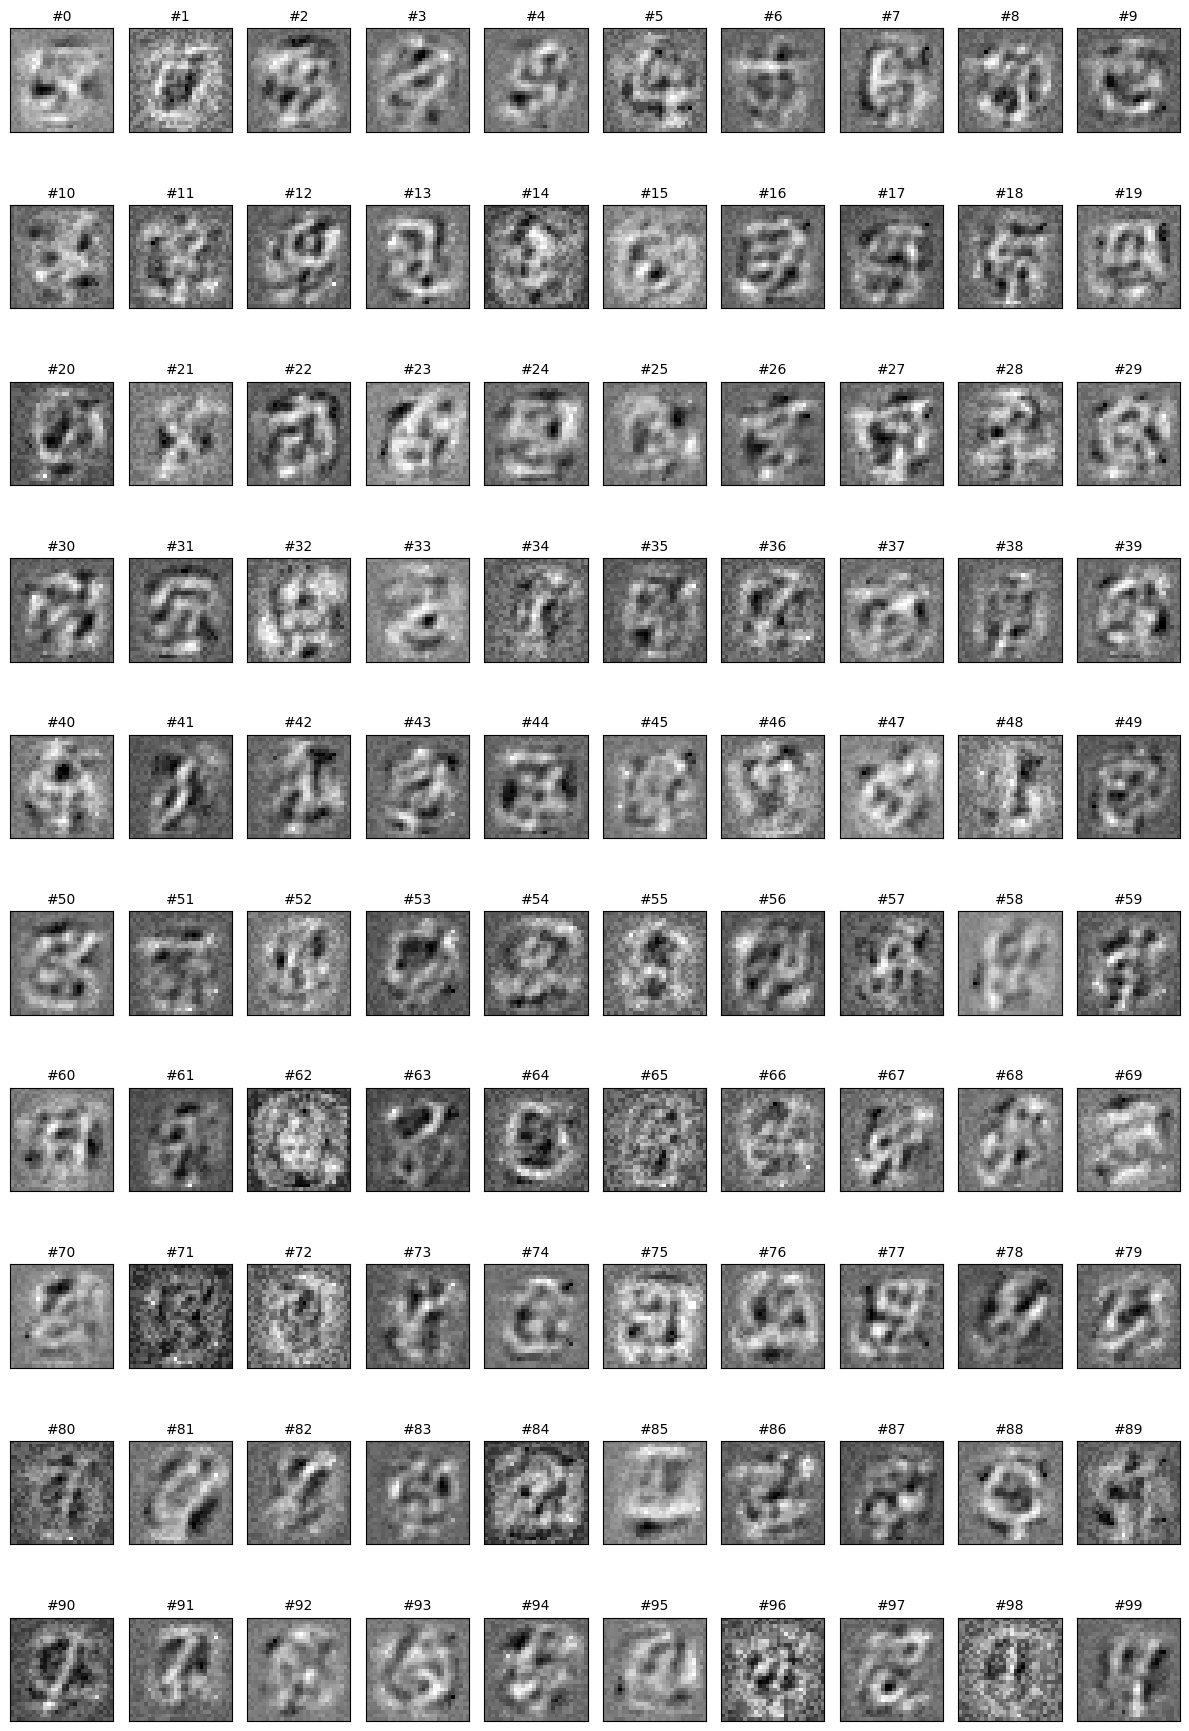

In [34]:
# @launchit.disable
bases_in_row = 10
max_filters_to_show = 100
fig, axes = plt.subplots(
    int(np.ceil(min(max_filters_to_show, pretrain_model.daes[0].encoder.out_features) / bases_in_row)), 
    bases_in_row,
    subplot_kw={'yticks': [], 'xticks': []}
)
fig.set_figwidth(12)
fig.set_figheight(18)
filters = pretrain_model.daes[0].encoder.weight.to(device='cpu').detach()

for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(ArrayUtils.v2sm(f), cmap='gray')

plt.tight_layout()

# Supervised training

Alternatively, as illustrated in Figure 4, a logistic regression layer can be added on top of the encoders, yielding a deep neural network amenable to supervised learning. The parameters of **all layers** can then be **simultaneously fine-tuned** using a gradient-based procedure such as stochastic gradient descent. 

## Dataset

In [34]:
def create_dataset_for_supervised_training(name, scaler):
    images, labels = get_mnist_images(name)
    images, scaler = preprocess_images(images, HP.images.preprocessing, scaler)
    images = torch.Tensor(images)
    images = images.contiguous() # force dense memory layout (speeds up DataLoader x2 in case of any transposes within preprocess_images)
    dataset = StackDataset(images, labels)
    return dataset, scaler

In [35]:
train_dataset, scaler = create_dataset_for_supervised_training('TRAIN', scaler=None)
test_dataset, _ = create_dataset_for_supervised_training('TEST', scaler=scaler)

## Pretrained model

In [58]:
if HP.override_pretrain_model_version is not None:
    model_registry = new_model_registry()
    meta = json.load(io.BytesIO(model_registry.get_asset_content(MODEL_INSTANCE_INFO.name, HP.override_pretrain_model_version, 'meta')))
    old_hp = Hyperparameters.from_dict(meta['hypers'])
    pprint.pprint(old_hp._asdict())
    pretrain_model = StackedDAE(train_dataset.datasets[0].shape[1], old_hp.pretrain_model)
    pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
    pt_data = model_registry.get_asset_content(MODEL_INSTANCE_INFO.name, HP.override_pretrain_model_version, 'pretrain_pt')
    pt_data = io.BytesIO(initial_bytes=pt_data)
    checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
    pretrain_model.load_state_dict(checkpoint['model_state_dict'])
    print(f'Pretrain model instance loaded from version={HP.override_pretrain_model_version}')

{'images': {'preprocessing': 'UNINORM'},
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 300,
                 'learn_rate': 0.01,
                 'loss': 'BCE',
                 'noise': 'Masking_0.4',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': None,
 'training': {'batch_size': 1000,
              'epochs_count': 500,
              'learn_rate': 0.001,
              'optimizer': 'Adam'}}
Pretrain model instance loaded from version=17


## Model: DeepLinearRegression

In [29]:
class DeepLinearRegression(tnn.Module):
    def __init__(self, stacked_dae, classes_count):
        super().__init__()
        self.stacked_dae = stacked_dae
        self.linear_regression = tnn.Linear(stacked_dae.daes[-1].encoder.out_features, classes_count)

    def forward(self, inp):
        encoded = self.stacked_dae.encode(inp)
        return self.linear_regression(encoded)

In [127]:
model = DeepLinearRegression(pretrain_model, 10)
sum([p.numel() for p in model.parameters()])

2799794

## Training

In [71]:
optimizers = {
    'SGD': lambda parameters, lr: topt.SGD(parameters, lr),
    'Adam': lambda parameters, lr: topt.Adam(parameters, lr),
}

# @launchit.disable
# @launchit.collect
HP.training.batch_size = 1_000
HP.training.epochs_count = 300
HP.training.optimizer = 'Adam'
HP.training.learn_rate = 0.001
# @launchit.stop
pprint.pprint(HP._asdict())

{'images': {'preprocessing': 'UNINORM'},
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 500,
                 'learn_rate': 0.01,
                 'loss': 'BCE',
                 'noise': 'Masking_0.4',
                 'optimizer': 'Adam',
                 'regularization': None},
 'training': {'batch_size': 100,
              'epochs_count': 100,
              'learn_rate': 0.01,
              'optimizer': 'Adam'}}


In [72]:
data_loader = DataLoader(train_dataset, batch_size=HP.training.batch_size, pin_memory=CONFIG.is_cuda, shuffle=True)
classes_count = 10
assert torch.all(train_dataset.datasets[1].unique() == torch.arange(classes_count))
model = DeepLinearRegression(pretrain_model, classes_count)
model = model.to(device=CONFIG.cuda_device)
loss_fn = tnn.CrossEntropyLoss()
optimizer = optimizers[HP.training.optimizer](model.parameters(), lr=HP.training.learn_rate)

In [ ]:
test_images = test_dataset.datasets[0].to(device=CONFIG.cuda_device)
test_labels = test_dataset.datasets[1].to(device=CONFIG.cuda_device)

for epoch_ind in tqdm(range(HP.training.epochs_count), 'Epoch'):
    epoch = epoch_ind + 1
    train_loss_sum, train_loss_denom = 0, 0
    train_accuracy_sum, train_accuracy_denom = 0, 0
    
    for batch in data_loader:
        optimizer.zero_grad()
        
        images = batch[0].to(device=CONFIG.cuda_device)
        labels = batch[1].to(device=CONFIG.cuda_device)
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        
        optimizer.step()
        
        train_loss_sum += loss.item() * len(batch)
        train_loss_denom += len(batch)
        train_accuracy_sum += (logits.argmax(axis=1) == labels).sum() # how many corrected predictions
        train_accuracy_denom += len(labels)

    assert train_loss_denom > 0
    assert train_accuracy_denom > 0
    summary_writer.add_scalar('train_loss', train_loss_sum / train_loss_denom, epoch)
    summary_writer.add_scalar('train_accuracy', train_accuracy_sum / train_accuracy_denom, epoch)

    with torch.no_grad():
        test_logits = model(test_images)
        test_loss = loss_fn(test_logits, test_labels)
        predicted_test_labels = test_logits.argmax(axis=1)
        test_accuracy = (predicted_test_labels == test_labels).sum() / len(test_labels)
        summary_writer.add_scalar('test_loss', test_loss, epoch)
        summary_writer.add_scalar('test_accuracy', test_accuracy, epoch)
    
    summary_writer.flush()

## Save

In [75]:
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'train_pt', replace=True)

# Supervised SVC (classification)

## Pretrained model

To this end, we fed the representations learnt by the purely unsupervised phase of SDAE, at increasing higher levels (first, second and third hidden layer) to both a linear SVM and a Kernel SVM (using a RBF kernel). The hyperparameters of the SVM and its kernel were tuned on the validation set as usual. For computational reasons, we did not re-tune SDAE hyperparameters. Instead, we identified the best performing SDAE-pretrained neural networks with 1000 units per layer, based on their validation performance after fine-tuning from previous experiments, but used their saved weights prior to fine-tuning (i.e., after unsupervised denoising training only).

In [30]:
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=17) # <- specifty desired one
pretrain_stacked_dae_asset = 'pretrain_pt'

# MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=86) # <- specifty desired one
# pretrain_stacked_dae_asset = 'train_pt' # aka fine-tuned (some sort of cheating, because trained model was selected based on test accuracy)

In [31]:
# @launchit.disable
train_images, _ = get_mnist_images('TRAIN')
model_registry = new_model_registry(is_real=True)
meta = json.load(io.BytesIO(model_registry.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'meta')))
old_hp = Hyperparameters.from_dict(meta['hypers'])
pprint.pprint(old_hp._asdict())

pretrain_model = StackedDAE(train_images.shape[1], old_hp.pretrain_model)
pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
pt_data = model_registry.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, pretrain_stacked_dae_asset)
pt_data = io.BytesIO(initial_bytes=pt_data)
checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))

if pretrain_stacked_dae_asset == 'pretrain_pt':
    pretrain_model.load_state_dict(checkpoint['model_state_dict'])
elif pretrain_stacked_dae_asset == 'train_pt':
    fined_tuned_model = DeepLinearRegression(pretrain_model, 10)
    fined_tuned_model.load_state_dict(checkpoint['model_state_dict']) # implicit load of pretrain model
else:
    assert False, pretrain_stacked_dae_asset
    
pretrain_model.eval()

{'images': {'preprocessing': 'UNINORM'},
 'override_pretrain_model_version': None,
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 300,
                 'learn_rate': 0.01,
                 'loss': 'BCE',
                 'noise': 'Masking_0.4',
                 'optimizer': 'Adam',
                 'regularization': None},
 'random_seed': None,
 'training': {'batch_size': 1000,
              'epochs_count': 500,
              'learn_rate': 0.001,
              'optimizer': 'Adam'}}


StackedDAE(
  (daes): ModuleList(
    (0): DenoiseAutoencoder(
      (encoder): Linear(in_features=784, out_features=1000, bias=True)
    )
    (1-2): 2 x DenoiseAutoencoder(
      (encoder): Linear(in_features=1000, out_features=1000, bias=True)
    )
  )
)

## Train & test datasets

In [32]:
# @launchit.disable
def create_dataset_for_classification(images, image_labels, model):
    features_list = []
    labels_list = []
    assert len(images) == len(image_labels)
    data_loader = DataLoader(list(zip(torch.Tensor(images), image_labels)), batch_size=100)
    
    for images, labels in tqdm(data_loader):
        images = torch.Tensor(images).to(device=CONFIG.cuda_device)
        
        with torch.no_grad():
            features = model.encode(images)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    
    x = np.vstack(features_list).astype('float64') # float64 is recommended for SVC
    y = np.hstack(labels_list)
    return x, y

In [33]:
# @launchit.disable
train_images, train_image_labels = get_mnist_images('TRAIN')
train_images, train_images_scaler = preprocess_images(train_images, HP.images.preprocessing)
x_train, y_train = create_dataset_for_classification(train_images, train_image_labels, pretrain_model)

  0%|          | 0/600 [00:00<?, ?it/s]

In [34]:
# @launchit.disable
test_images, test_image_labels = get_mnist_images('TEST')
test_images, _ = preprocess_images(test_images, HP.images.preprocessing, train_images_scaler) # train_images_scaler is a must!!!
x_test, y_test = create_dataset_for_classification(test_images, test_image_labels, pretrain_model)

  0%|          | 0/100 [00:00<?, ?it/s]

## SVC

In [44]:
%%time
pipeline = make_pipeline(
    # StandardScaler(), # scaler adds too much time to execution. The problem is in DATA itself - non-scaled data is way too faster to fit :-(
    LinearSVC(C=1, penalty='l2', max_iter=100, random_state=HP.random_seed)
)
pipeline.fit(x_train, y_train)
pipeline.score(x_test, y_test)

CPU times: user 2min 19s, sys: 267 ms, total: 2min 20s
Wall time: 2min 20s


/home/misha/anaconda3/envs/mine/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`

In [55]:
%%time
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
pipeline = make_pipeline(
    StandardScaler(),
    LDA(),
    LinearSVC(C=1, max_iter=100, random_state=HP.random_seed)
)
pipeline.fit(x_train, y_train)
pipeline.score(x_test, y_test)

CPU times: user 1min 14s, sys: 644 ms, total: 1min 15s
Wall time: 8.57 s


0.9689

In [28]:
%%time
# @launchit.disable
n_jobs = None if CONFIG.is_cuml else -1 # using all CPUs (-1) showed to be a bad idea with CUML - no perf gain, but huge impact on CPU and GPU

parameters = {'C': np.linspace(0.01, 1, 3), 'penalty': ['l1', 'l2'], 'max_iter': [100], 'random_state': [HP.random_seed]}
# parameters = {'C': np.linspace(0.01, 1, 3), 'max_iter': [100], 'random_state': [HP.random_seed]}
search_svm = GridSearchCV(LinearSVC(), parameters, n_jobs=n_jobs)

# parameters = {'C': np.linspace(0.01, 1, 10), 'kernel': ['linear', 'rbf'], 'max_iter': [1000], 'random_state': [HP.random_seed]}
# parameters = {'C': np.linspace(3, 5, 5), 'gamma': np.linspace(0.01, 1, 5), 'kernel': ['rbf'], 'max_iter': [1000], 'random_state': [HP.random_seed]}
# search_svm = GridSearchCV(SVC(cache_size=1_000), parameters, n_jobs=n_jobs)

search_svm.fit(x_train, y_train)
svm = search_svm.best_estimator_
# vars(svm)

# svm = SVC(max_iter=300, kernel='rbf', C=1, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9772
# svm = SVC(max_iter=300, kernel='rbf', C=1.5, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9805
# svm = SVC(max_iter=300, kernel='rbf', C=4.555, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9808
# svm = SVC(max_iter=2_000, kernel='rbf', C=4.555, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9808
# svm = SVC(max_iter=100, kernel='rbf', C=3.8889, cache_size=1_000, random_state=HP.random_seed) # version=2, 0.9808
# svm.fit(x_train, y_train)

CPU times: user 46.2 s, sys: 1.23 s, total: 47.5 s
Wall time: 1min 57s


{'dual': 'auto',
 'tol': 0.0001,
 'C': np.float64(0.505),
 'multi_class': 'ovr',
 'fit_intercept': True,
 'intercept_scaling': 1,
 'class_weight': None,
 'verbose': 0,
 'random_state': 8231,
 'max_iter': 100,
 'penalty': 'l2',
 'loss': 'squared_hinge',
 'n_features_in_': 1000,
 'classes_': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 'coef_': array([[-0.41556793,  0.05779941,  0.13622412, ..., -0.2026    ,
         -0.10577372,  0.13710795],
        [-0.16678968, -0.18609544, -0.06003702, ...,  0.06304661,
         -0.08960933, -0.06246719],
        [-0.73647787, -0.36252262,  0.34386448, ..., -0.19613223,
          0.29601313,  0.12040138],
        ...,
        [ 0.1052008 , -0.16385383, -0.03051754, ...,  0.00815348,
         -0.37845664, -0.4009994 ],
        [-0.31779411, -0.1235381 ,  0.09576726, ..., -0.41577996,
          0.73858333,  0.1688878 ],
        [ 0.25550595, -0.16910542, -0.28027716, ...,  0.29315293,
          0.9514011 ,  0.18120656]], shape=(10, 1000)),
 'intercept_': a

## SVC performance

In [72]:
%%time
# @launchit.disable
accuracy = svm.score(x_test, y_test)
print(f'Accuracy={accuracy}')

parameters = {
    'C': svm.C, 
    'max_iter': svm.max_iter, 
    'random_state': svm.random_state, 
}

if isinstance(svm, SVC):
    parameters['kernel'] = svm.kernel
    parameters['gamma'] = svm.gamma
elif isinstance(svm, LinearSVC):
    parameters['penalty'] = svm.penalty
    parameters['loss'] = svm.loss
    
summary_log_dir = os.path.join(MODEL_INSTANCE_INFO.name, str(MODEL_INSTANCE_INFO.version))
new_summary_writer(log_dir=summary_log_dir, is_real=True).add_hparams(
    parameters, 
    {'accuarcy': accuracy},
    run_name=f'{datetime.datetime.now().strftime('%y%m%d:%H%M%S')}')

CPU times: user 1min 9s, sys: 12.6 ms, total: 1min 9s
Wall time: 1min 9s


0.9805